# Feature Extraction notebook

In [80]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use project root relative to this notebook
BASE_DIR = Path('/home/amraas/projects/realestatecons')
DATA_DIR = BASE_DIR / 'data' / 'raw'

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

In [81]:
import sys

sys.path.append(str(BASE_DIR))

from src.data.preprocess import clean_test_data, clean_train_data
from src.features.features import add_engineered_features

In [82]:
train_df_cleaned = clean_train_data(train_df)
test_df_cleaned = clean_test_data(test_df, train_df)

train_df_features = add_engineered_features(train_df_cleaned)
test_df_features = add_engineered_features(test_df_cleaned)

In [83]:
train_df_cleaned.isnull().sum().value_counts()

0    80
Name: count, dtype: int64

In [84]:
test_df_cleaned.isnull().sum().value_counts()

0    79
Name: count, dtype: int64

## Possible features
- Total Living Area
TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
- Total Bathrooms
TotalBath = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
- Total Porch Area
TotalPorchSF = OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
- Total Outdoor Area
OutdoorSF = WoodDeckSF + TotalPorchSF + PoolArea
- Rooms Density
RoomDensity = GrLivArea / TotRmsAbvGrd
- Age = YrSold - YearBuilt

In [85]:
train_df_features.head()

test_df_features.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBath,TotalPorchSF,OutdoorSF,RoomDensity,Age
0,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,6,2010,WD,Normal,1778.0,1.0,120,260,179.200000,49
1,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,6,2010,WD,Normal,2658.0,1.5,36,429,221.500000,52
2,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,3,2010,WD,Normal,2557.0,2.5,34,246,271.500000,13
3,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,...,6,2010,WD,Normal,2530.0,2.5,36,396,229.142857,12
4,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,...,1,2010,WD,Normal,2560.0,2.0,226,226,256.000000,18


## Feature exploration and reduction

### initial target left skewness 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f5530752f10>,
 'caps': [<matplotlib.lines.Line2D at 0x7f5530752a10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f5530753ed0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f5531257650>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f552bd28d90>],
 'means': []}

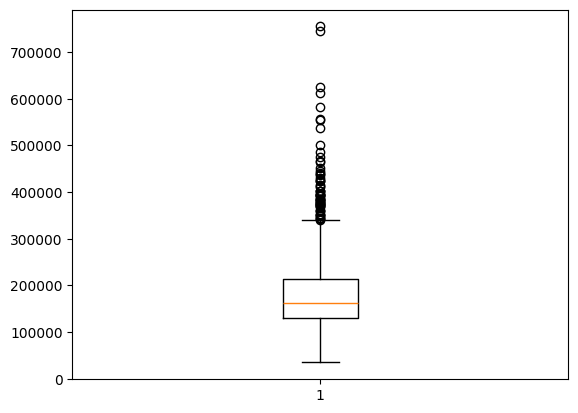

In [86]:
plt.boxplot(train_df_features['SalePrice'])

In [87]:
fancy_houses = train_df_features[train_df_features['SalePrice']>=train_df_features['SalePrice'].quantile(0.9)].head(10)
fancy_houses

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,OutdoorSF,RoomDensity,Age
6,20,RL,75.0,10084,Pave,None,Reg,Lvl,AllPub,Inside,...,2007,WD,Normal,307000,3380,3.0,57,312,242.000000,3
11,60,RL,85.0,11924,Pave,None,IR1,Lvl,AllPub,Inside,...,2006,New,Partial,345000,3499,4.0,21,168,211.272727,1
13,20,RL,91.0,10652,Pave,None,IR1,Lvl,AllPub,Inside,...,2007,New,Partial,279500,2988,2.0,33,193,213.428571,1
20,60,RL,101.0,14215,Pave,None,IR1,Lvl,AllPub,Corner,...,2006,New,Partial,325300,3534,3.5,154,394,264.000000,1
27,20,RL,98.0,11478,Pave,None,Reg,Lvl,AllPub,Inside,...,2010,WD,Normal,306000,3408,3.0,50,50,243.428571,3
35,60,RL,108.0,13418,Pave,None,Reg,Lvl,AllPub,Inside,...,2006,WD,Normal,309000,3569,3.5,32,145,272.444444,2
45,120,RL,61.0,7658,Pave,None,Reg,Lvl,AllPub,Inside,...,2010,WD,Normal,319900,3504,3.0,82,278,292.000000,5
53,20,RL,68.0,50271,Pave,None,IR1,Low,AllPub,Inside,...,2006,WD,Normal,385000,3684,2.5,72,929,368.400000,25
58,60,RL,66.0,13682,Pave,None,IR2,HLS,AllPub,CulDSac,...,2006,New,Partial,438780,4355,3.5,37,229,294.500000,0
65,60,RL,76.0,9591,Pave,None,Reg,Lvl,AllPub,Inside,...,2007,WD,Normal,317000,3616,2.5,151,343,274.777778,3


In [88]:
fancy_houses['TotalSF'].sort_values(ascending=False)

58    4355
53    3684
65    3616
35    3569
20    3534
45    3504
11    3499
27    3408
6     3380
13    2988
Name: TotalSF, dtype: int64

In [89]:
train_df_features['TotalSF'].mean()

np.float64(2567.0486301369865)

- given high price houses (outliers) have much larger area (sample feature), they might be reasonable to keep and not noisy

### Correlation and PairPlots

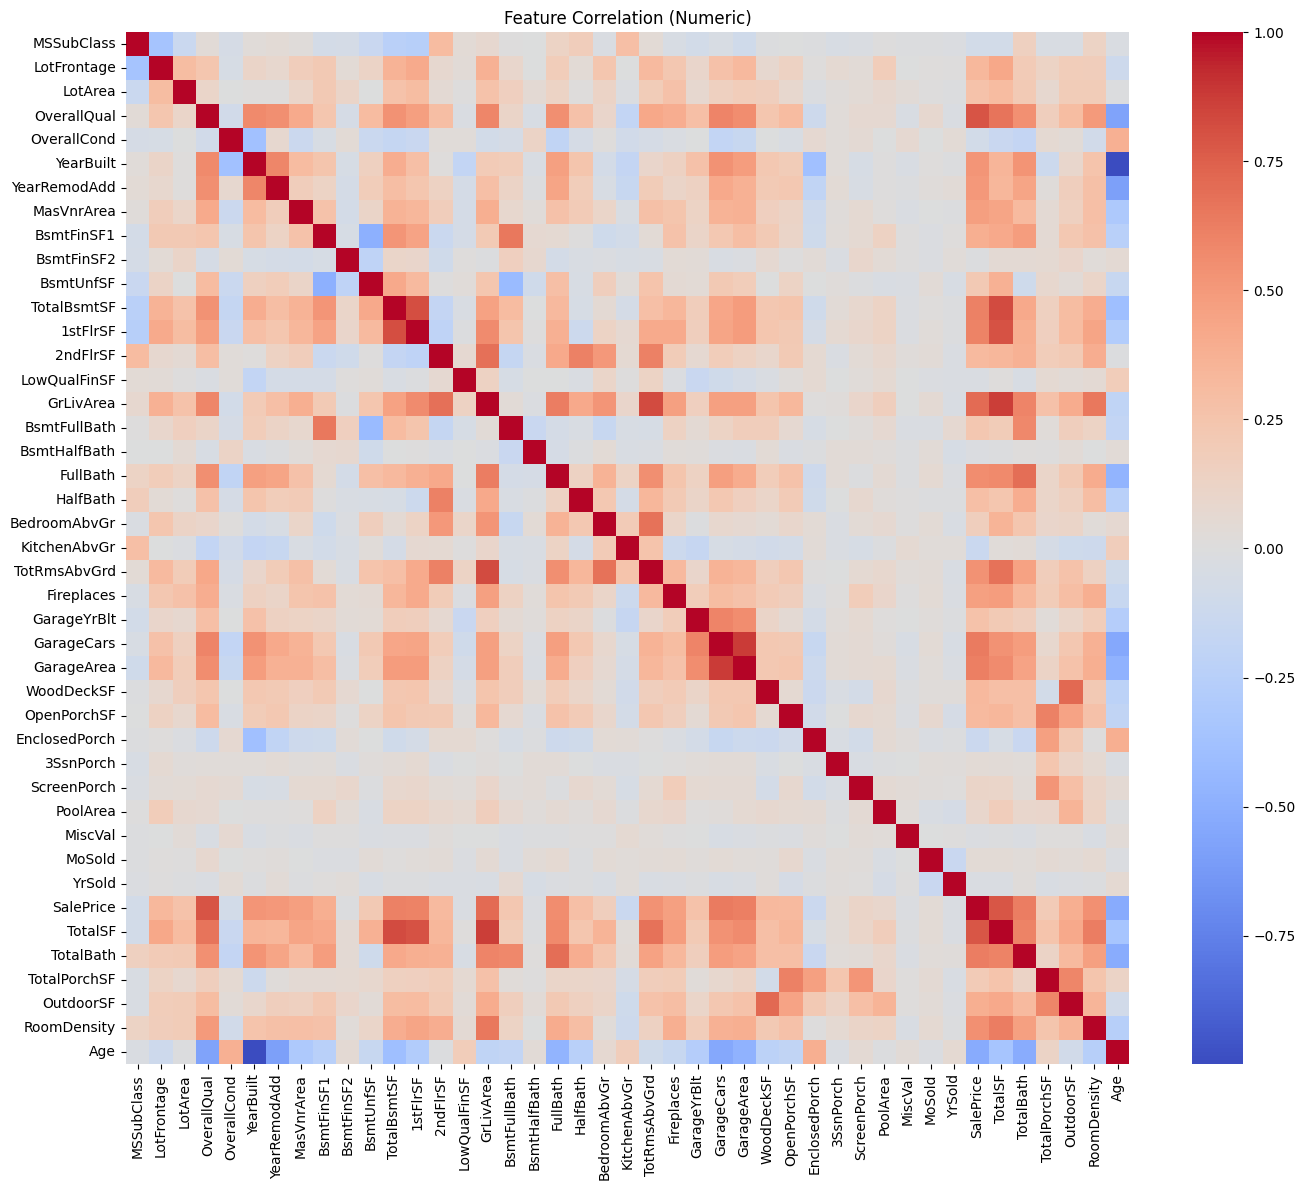

OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
GarageCars      0.640409
TotalBath       0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
RoomDensity     0.540645
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
OutdoorSF       0.390365
BsmtFinSF1      0.386420
LotFrontage     0.334771
WoodDeckSF      0.324413
2ndFlrSF        0.319334
Name: SalePrice, dtype: float64

In [90]:
import seaborn as sns

numeric_df = train_df_features.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation (Numeric)")
plt.tight_layout()
plt.show()

target_corr = corr["SalePrice"].drop("SalePrice").sort_values(ascending=False)
target_corr.head(20)

In [91]:
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "FeatureA", "level_1": "FeatureB", 0: "AbsCorr"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["AbsCorr"] >= 0.85]
high_corr_pairs = high_corr_pairs[
    ~high_corr_pairs["FeatureA"].isin(["SalePrice"]) 
    & ~high_corr_pairs["FeatureB"].isin(["SalePrice"])
].sort_values("AbsCorr", ascending=False)

print("Highly correlated feature pairs (|corr| >= 0.85):")
print(high_corr_pairs)

high_corr_features = sorted(
    set(high_corr_pairs["FeatureA"]).union(set(high_corr_pairs["FeatureB"]))
)
print("\nFeatures involved in high correlation:", high_corr_features)

Highly correlated feature pairs (|corr| >= 0.85):
        FeatureA    FeatureB   AbsCorr
257    YearBuilt         Age  0.999036
1101  GarageCars  GarageArea  0.882475
682    GrLivArea     TotalSF  0.874373

Features involved in high correlation: ['Age', 'GarageArea', 'GarageCars', 'GrLivArea', 'TotalSF', 'YearBuilt']


### drop 1 of each highly correlated feature pair

In [92]:
highly_corr_to_drop = ['YearBuilt', 'GarageArea','GrLivArea']
test_df_features = test_df_features.drop(highly_corr_to_drop, axis = 1)
train_df_features = train_df_features.drop(highly_corr_to_drop, axis = 1)

In [93]:
drop_map = {}
for feature in highly_corr_to_drop:
    related = high_corr_pairs[
        (high_corr_pairs["FeatureA"] == feature)
        | (high_corr_pairs["FeatureB"] == feature)
    ]
    drop_map[feature] = related[["FeatureA", "FeatureB", "AbsCorr"]]

print("Dropped feature mapping to correlated pairs:")
for feature, pairs in drop_map.items():
    print(f"\n{feature}:")
    print(pairs)

Dropped feature mapping to correlated pairs:

YearBuilt:
      FeatureA FeatureB   AbsCorr
257  YearBuilt      Age  0.999036

GarageArea:
        FeatureA    FeatureB   AbsCorr
1101  GarageCars  GarageArea  0.882475

GrLivArea:
      FeatureA FeatureB   AbsCorr
682  GrLivArea  TotalSF  0.874373


In [94]:
target_corr_sorted = target_corr.sort_values(ascending=False)
print("Top features correlated with SalePrice:")
print(target_corr_sorted.head(30))

top_features = target_corr_sorted.head(15).index.tolist()
print("\nTop 15 features:", top_features)

Top features correlated with SalePrice:
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
GarageCars      0.640409
TotalBath       0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
RoomDensity     0.540645
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
OutdoorSF       0.390365
BsmtFinSF1      0.386420
LotFrontage     0.334771
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
LotArea         0.263843
GarageYrBlt     0.261366
BsmtFullBath    0.227122
BsmtUnfSF       0.214479
TotalPorchSF    0.195739
BedroomAbvGr    0.168213
ScreenPorch     0.111447
PoolArea        0.092404
Name: SalePrice, dtype: float64

Top 15 features: ['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'TotalBath', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'RoomDensity', 'TotRmsAbvGrd', 'YearBuil

### PairPlots

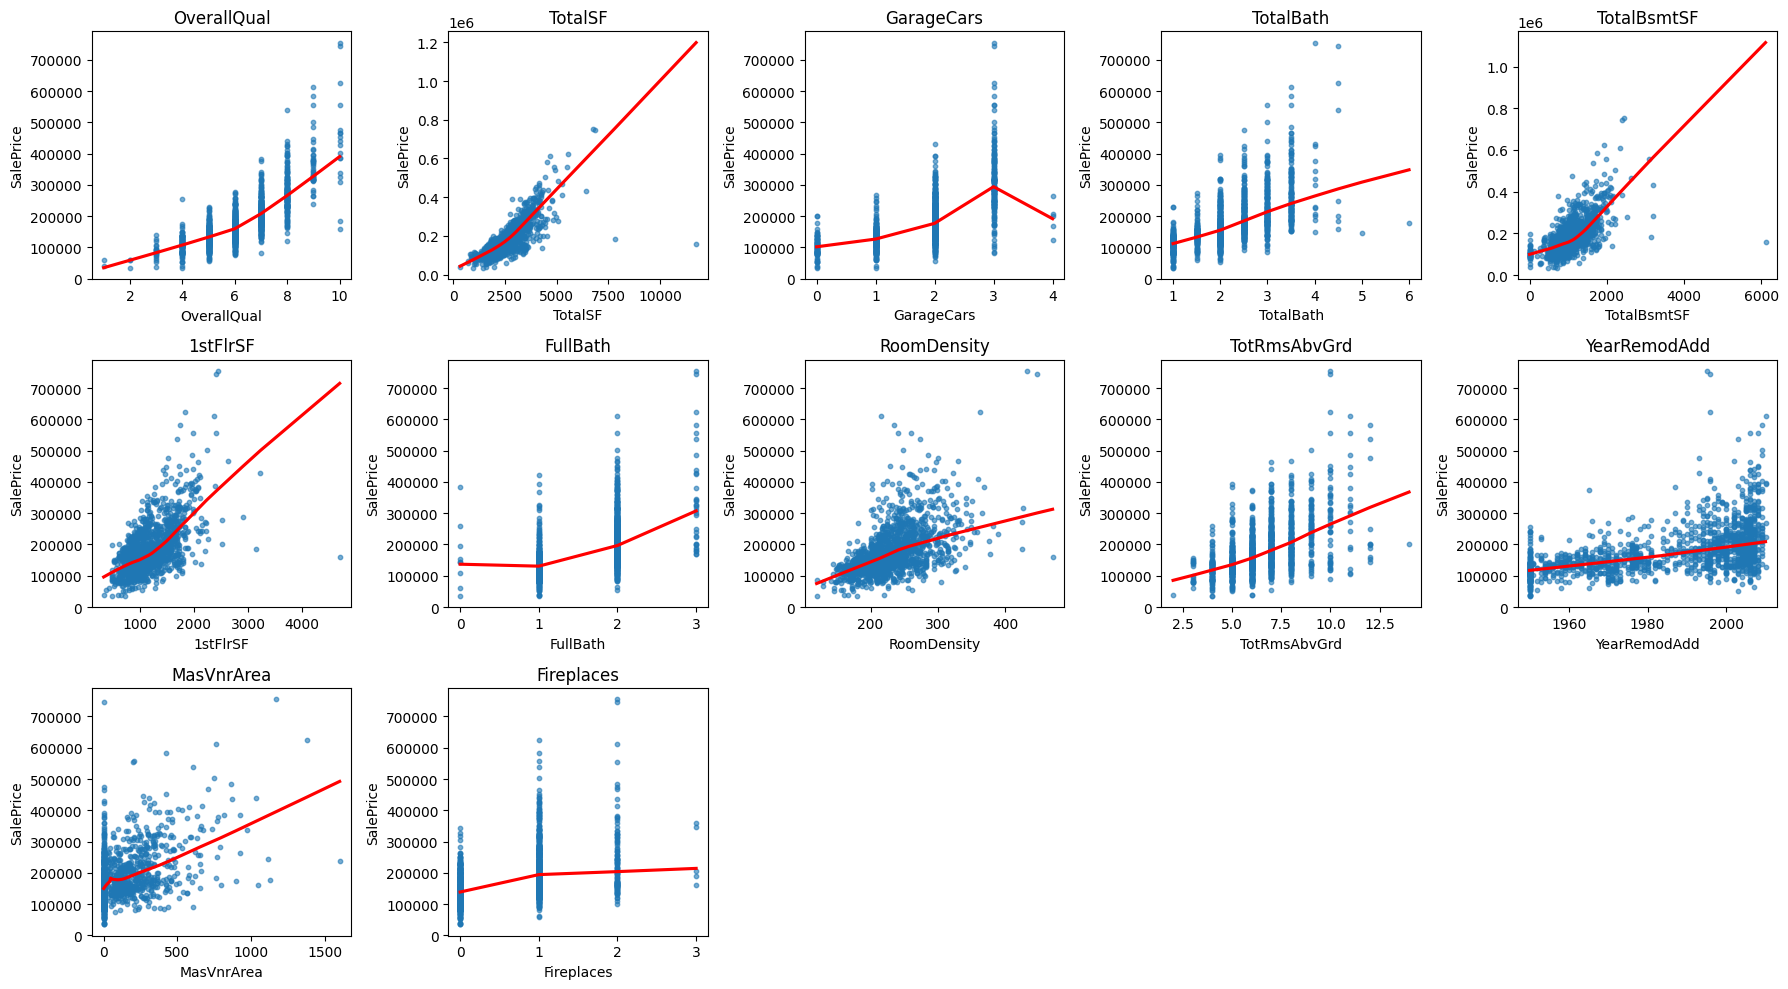

In [95]:
def plot_feature_grid(df, features, target="SalePrice", nrows=3, ncols=5):
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10))
    axes = axes.ravel()

    for idx, feature in enumerate(features):
        sns.regplot(
            data=df,
            x=feature,
            y=target,
            lowess=True,
            scatter_kws={"alpha": 0.6, "s": 10},
            line_kws={"color": "red"},
            ax=axes[idx],
        )
        axes[idx].set_title(feature)

    for idx in range(len(features), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

plot_feature_grid(train_df_features, [f for f in top_features if f not in highly_corr_to_drop])

In [96]:
numeric_df = train_df_features.select_dtypes(include=[np.number])
numeric_feature_names = [
    col for col in numeric_df.columns if col != "SalePrice"
]
feature_chunks = [
    numeric_feature_names[i : i + 15]
    for i in range(0, len(numeric_feature_names), 15)
]

def plot_feature_chunk(chunk_idx: int) -> None:
    if chunk_idx < 0 or chunk_idx >= len(feature_chunks):
        print("Chunk index out of range.")
        return
    chunk = feature_chunks[chunk_idx]
    print(f"Plotting chunk {chunk_idx + 1}/{len(feature_chunks)}: {chunk}")
    plot_feature_grid(train_df_features, chunk)

print(f"Total chunks: {len(feature_chunks)}")

Total chunks: 3


Plotting chunk 1/3: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath']


/home/amraas/miniconda3/envs/realestateconsultant/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


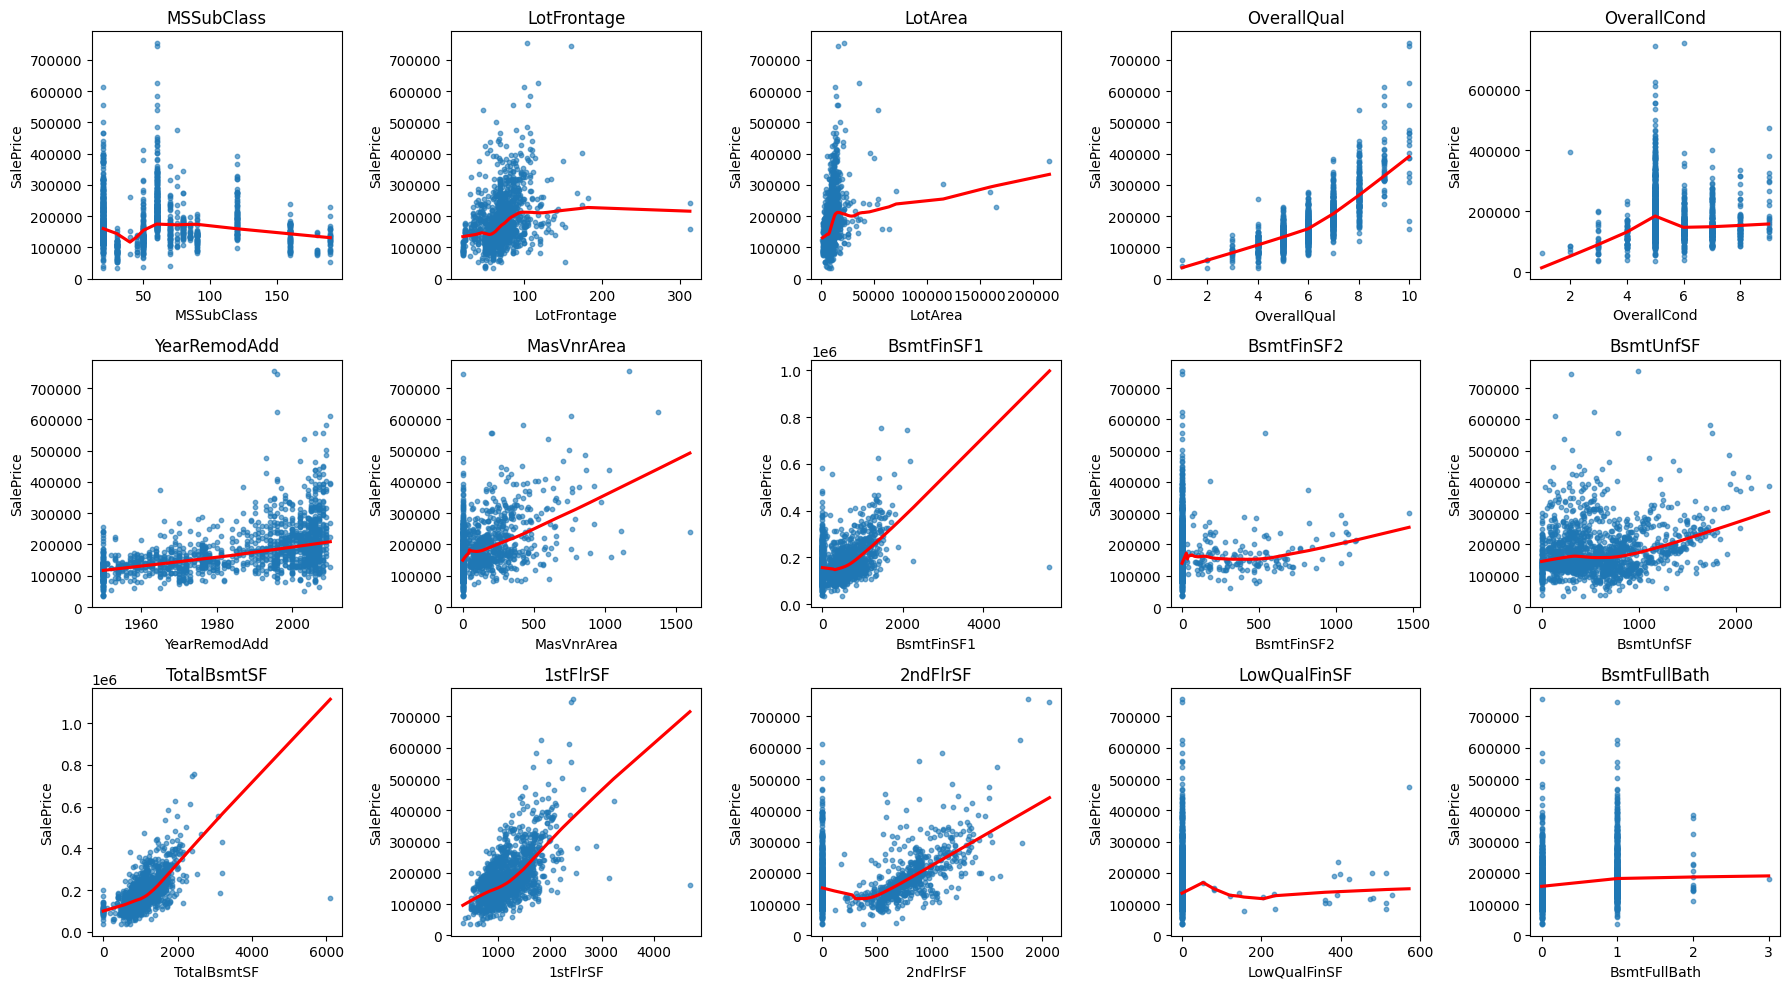

Plotting chunk 2/3: ['BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea']


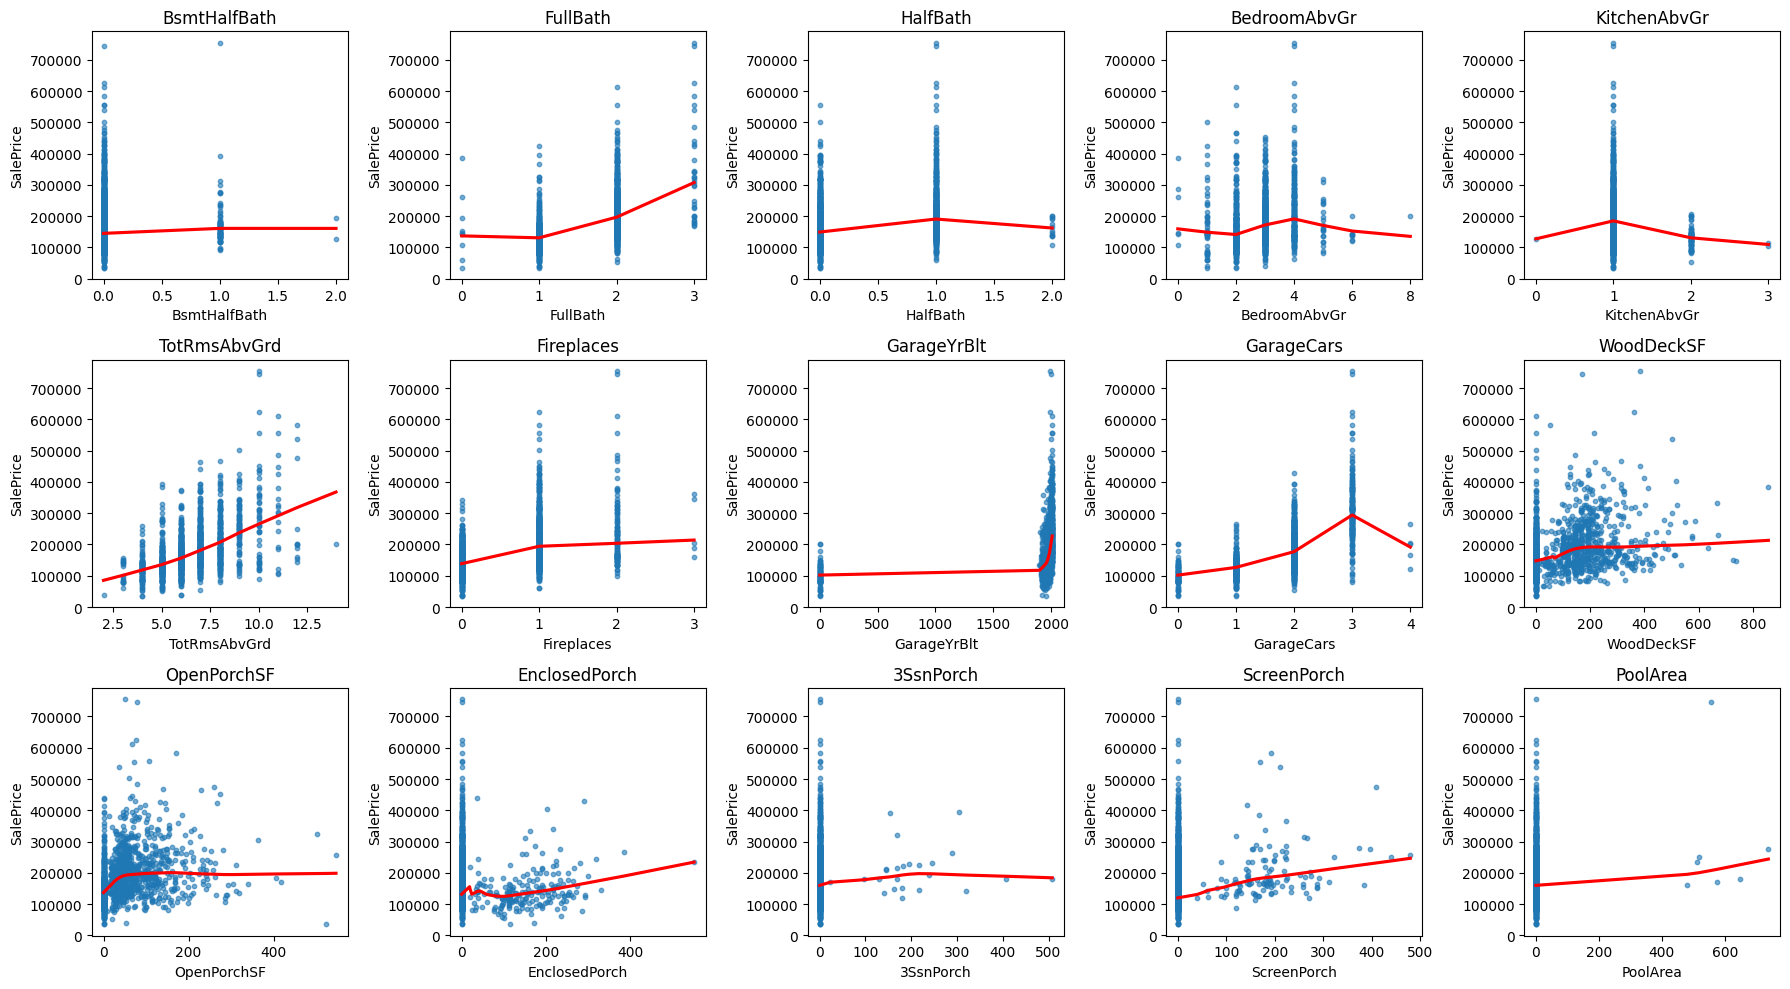

Plotting chunk 3/3: ['MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'OutdoorSF', 'RoomDensity', 'Age']


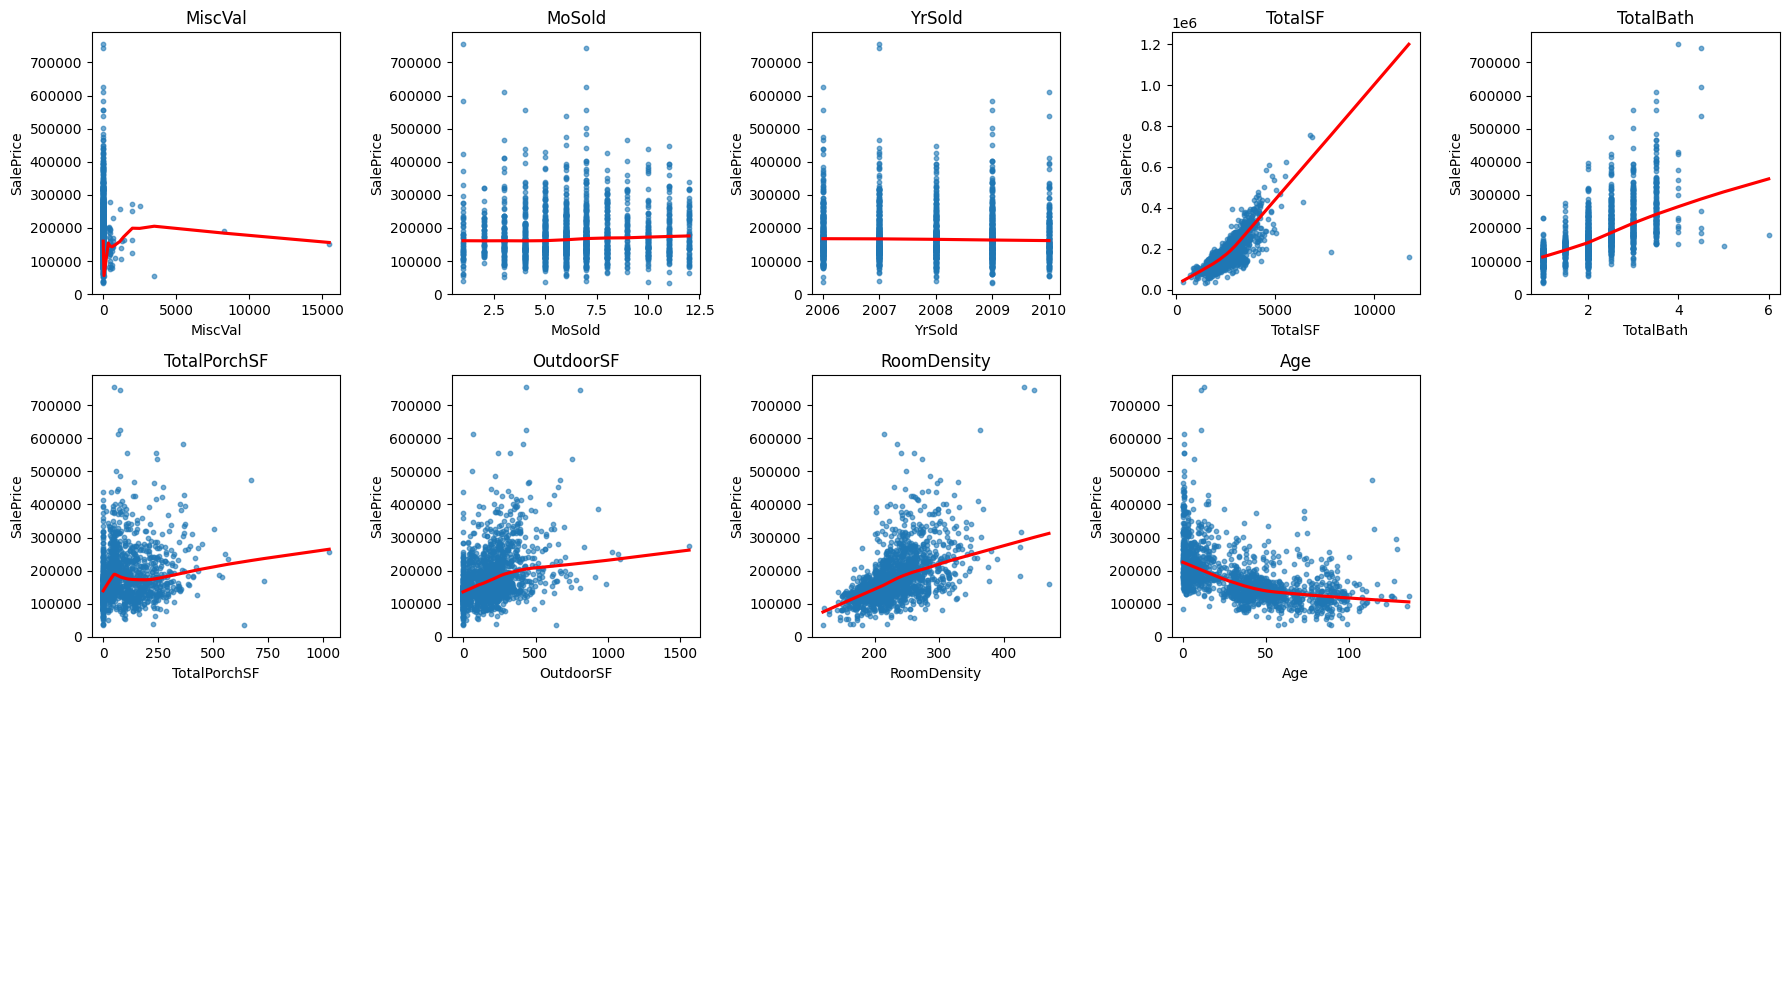

In [97]:
for chunk_idx in range(0, len(feature_chunks)):
    plot_feature_chunk(chunk_idx)

- no overly non linear relationships found in numerical features, we could proceed without log transformations currently

In [98]:
# train_df_features_X = train_df_features.copy()
# train_df_features_X["OverallQual_log"] = np.log1p(train_df_features["OverallQual"])

# sns.regplot(
#             data=train_df_features_X,
#             x="OverallQual_log",
#             y="SalePrice",
#             lowess=True,
#             scatter_kws={"alpha": 0.6, "s": 10},
#             line_kws={"color": "red"},
#         )
# plt.show()